# Convolutional Neural Network

<font color=#ff4600>Keras: <br>
https://keras.io/examples/vision/image_classification_from_scratch/</font>



### Importing the libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
tf.__version__

## Part 1 - Data Preprocessing

### Preprocessing the Training set

In [ ]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
training_set = train_datagen.flow_from_directory('dataset/training_set',
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

### Preprocessing the Test set

In [ ]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('dataset/test_set',
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'binary')

## Part 2 - Building the CNN

### Initialising the CNN

In [ ]:
cnn = tf.keras.models.Sequential()

### Step 1 - Convolution

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64, 64, 3]))

<b> <font color=#ff4600>filters = 32 (commonly used number) </font></b><br>
- number of learnable feature detectors / filters
- each filter produces 1 feature map (learns edge, texture, contrast etc.)
- output therefore has 32 feature maps

<div style="width:300px">

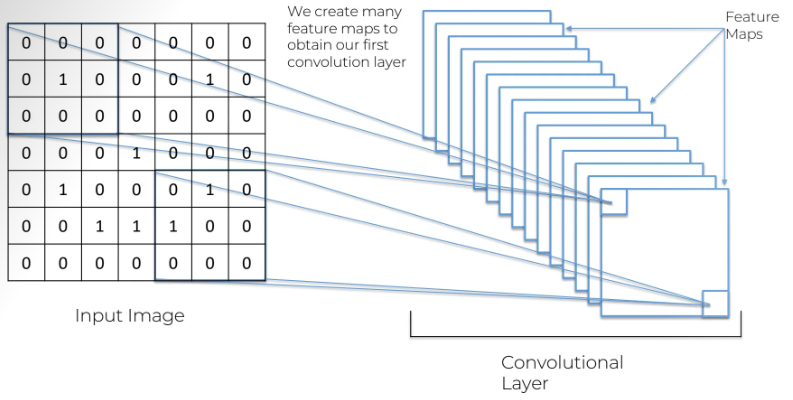

</div>

<b> <font color=#ff4600>kernel_size = 3 (size of the feature detector)</font></b><br>
- spatial size of each filter = 3x3
- first CNN layer: input has 3 RGB channels
- actual filter shape = 3x3x3

<div style="width:300px">

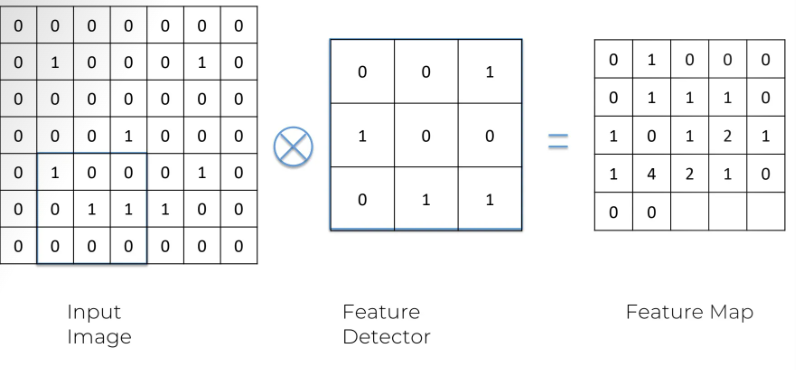

</div>

<b> <font color=#ff4600>input_shape = [64,64,3]</font></b><br>
- image size = 64x64 pixels
- 3 RGB channels

<b> <font color=#ff4600>activation='relu'</font></b><br>
- applied after convolution
- keeps positive values, set negative values to 0



### Step 2 - Pooling

In [ ]:
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))


<b> <font color=#ff4600>pool_size = 2</font></b><br>
- 2x2 window
- takes the maximum value inside each 2x2 area
<div style="width:800px">

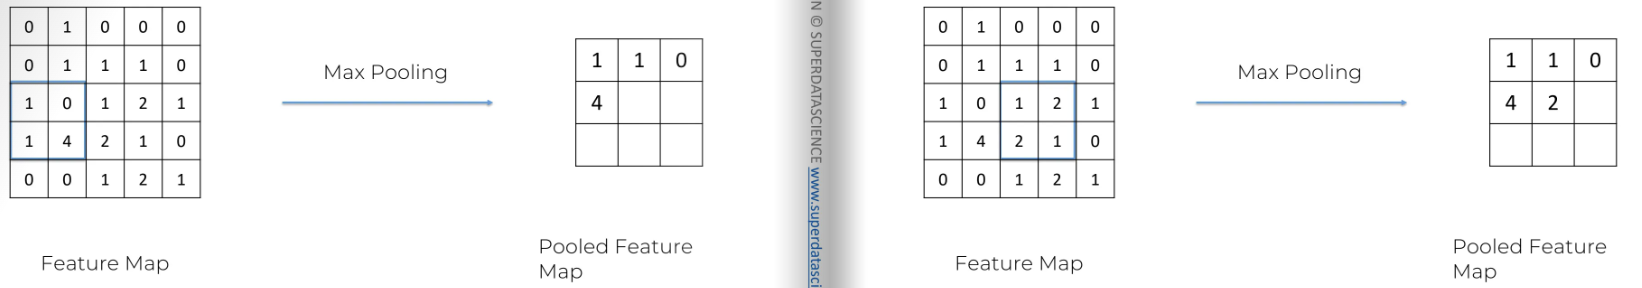

</div>

<b> <font color=#ff4600>strides = 2</font></b><br>
- pooling window moves 2 pixels each step
- reduces width and height by about half
<div style="width:800px">

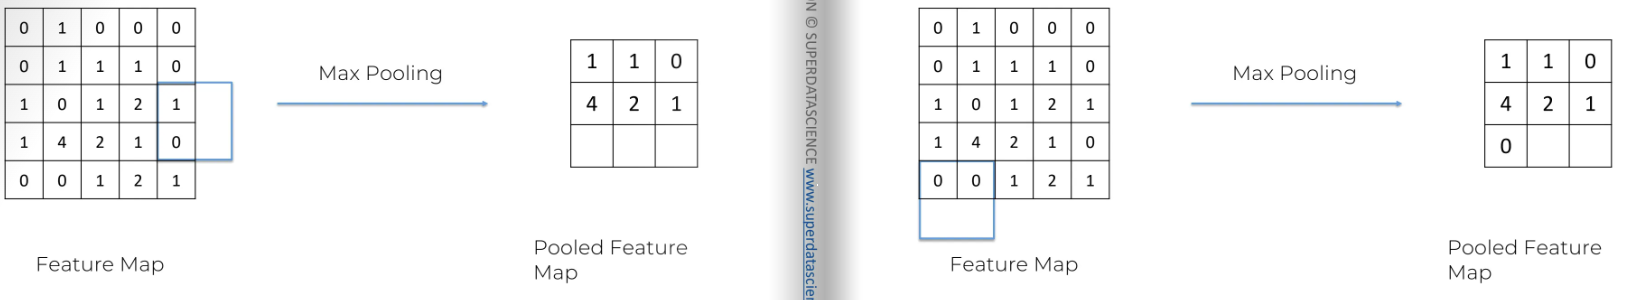

</div>



### Adding a second convolutional layer

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

<b> <font color=#ff4600>Input 64x64x3</font></b><br>

- Conv 1 / Conv 2
    - padding='valid', strides=1 by default
    - output size = floor((input + 2P - K) / S ) + 1
    - P = padding, number of pixels padded on each side
    - K = kernel size
    - S = strides


- <b> Conv 1</b>
    - 32 filters
    - each filter = 3x3x3
    - output = 62x62x32
    - 62 = (64 + 2 x 0 - 3) / 1 + 1

- <b> MaxPool 1</b>
    - pool window = 2x2
    - output = 31x31x32
    - 31 = floor((62-2) / 2)+1

- <b> Conv 2</b>
    - 32 filters
    - each filter = 3x3x32
    - output = 29x29x32 
    - 29 = (31 + 2 x 0 - 3) / 1 + 1

- <b> MaxPool 2</b>
    - pool window = 2x2
    - output = 14x14x32
    - 14 = floor((29-2) / 2)+1
    
- <b> Flatten</b>
    - a vector that contains 14x14x32 = 6272 values

### Step 3 - Flattening

In [ ]:
cnn.add(tf.keras.layers.Flatten())

### Step 4 - Full Connection

In [ ]:
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

### Step 5 - Output Layer

<b> <font color=#ff4600>Common practice:</font></b><br>

- <b>Binary Classification</b>: relu - relu - relu - sigmoid (output) + loss = 'binary_crossentropy'
- <b>Non-Binary Classification</b>: relu - relu - relu - softmax (output) + loss = 'categorical_crossentropy'

In [ ]:
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

## Part 3 - Training the CNN

### Compiling the CNN

In [ ]:
cnn.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

### Training the CNN on the Training set and evaluating it on the Test set

In [ ]:
cnn.fit(x = training_set, validation_data = test_set, epochs = 25)

## Part 4 - Making a single prediction

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
test_image = image.load_img('dataset/single_prediction/cat_or_dog_1.jpg', target_size = (64, 64))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
training_set.class_indices
if result[0][0] == 1:
  prediction = 'dog'
else:
  prediction = 'cat'

In [ ]:
print(prediction)